# Drifter Data Exploration
- show the spatial repartition of the drifters and identify clusters
- plot observations spatial density
- look at the drifters temporal resolution (for each cluster ?)

In [1]:
import os
from glob import glob

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.geodesic import Geodesic

import numpy as np
import xarray as xr
import pandas as pd

%matplotlib inline
from matplotlib import pyplot as plt

path_save_plot = './save_plots_2024-06-11_DrifterDataExploration/'

## Data selection

In [2]:
data_dir = '/home/bouxdecl/Documents/data/all_drifters_sharing'
L2_dir = data_dir + '/L2'
#os.listdir(L2_dir)

filename convention: L2_type_source_rawsampling_method_smoothedsampling_version.nc

In [118]:
mediterranea_files = []  

#only the files with uwa types are not in mediterranea
for file_name in os.listdir(L2_dir):
    if not file_name.count("uwa"):
        mediterranea_files.append(file_name)

mediterranea_files.remove(".DS_Store")
mediterranea_files[0:5]

['L2_svp_scripps_10min_lowess_10min_v0.nc',
 'L2_svp_ogs_1h_variational_10min_v0.nc',
 'L2_svp_bcg_10min_variational_10min_v0.nc',
 'L2_svp_scripps_10min_lowess_30min_v0.nc',
 'L2_melodi_eodyn_10min_variational_10min_v0.nc']

## Spaghetti plot

#### example of netcdf file :

In [4]:
f = mediterranea_files[0]
ds = xr.open_dataset(os.path.join(L2_dir, f))

ds

<xarray.Dataset>
Dimensions:     (id: 8, time: 3727)
Coordinates:
  * id          (id) <U15 '300534061395960' ... '300534064300510'
  * time        (time) datetime64[ns] 2023-05-04T20:10:00 ... 2023-05-30T17:1...
Data variables: (12/26)
    u           (id, time) float64 ...
    v           (id, time) float64 ...
    x           (id, time) float64 ...
    y           (id, time) float64 ...
    platform    (id) <U14 ...
    lonc        (id) float64 ...
    ...          ...
    start_lon   (id) float64 ...
    start_lat   (id) float64 ...
    end_time    (id) datetime64[ns] ...
    end_lon     (id) float64 ...
    end_lat     (id) float64 ...
    end_reason  (id) <U10 ...
Attributes: (12/15)
    drifter_type:                    SVP
    laboratory:                      SCRIPPS
    campaign:                        BIOSWOT
    campaign_doi:                    https://doi.org/10.17600/18002392
    raw_download_max_date:           2023-05-30 17:10:00
    contact:                         margot.demol@ifremer.fr
    ...                              ...
    geographical_projection:         Asimuthal Equidistant projection centere...
    geographical_projection_pyproj:  pyproj.Proj(proj="aeqd", lat_0=latc, lon...
    smoothing_method:                LOWESS
    smoothing_method_param_dict:     {'degree': 2, 'iteration': 3, 'T_low_pas...
    interpolation_sampling:          10min
    nominal_raw_sampling:            10min

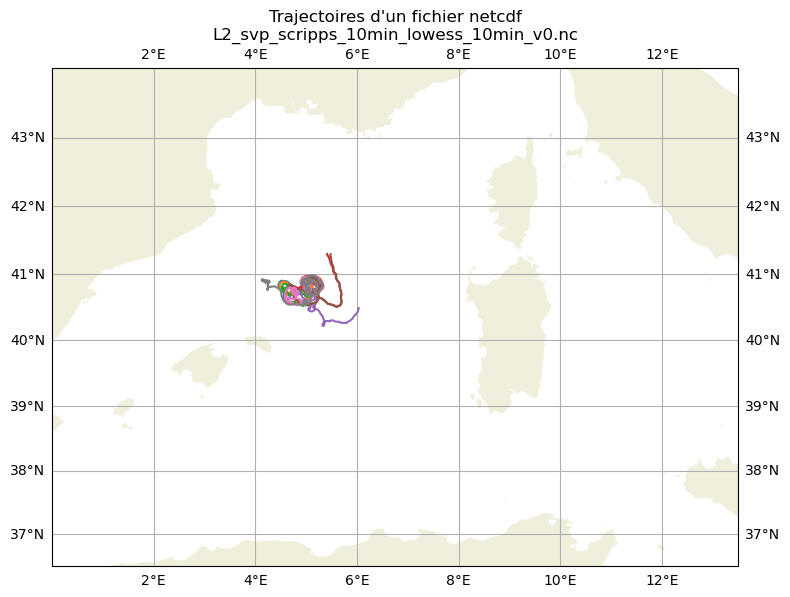

In [35]:
fig = plt.figure(tight_layout=True, figsize=(8, 8))
crs = ccrs.PlateCarree()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
gl = ax.gridlines(draw_labels=True,)

ax.add_feature(cfeature.LAND,)
bbox = [0,13.5, 36.5,44]
ax.set_extent(bbox)
ax.set_title("Trajectoires d'un fichier netcdf\n{}".format(f))

for i in range(ds.sizes['id']):
    ax.plot(ds.isel(id=i).lon, ds.isel(id=i).lat,transform=crs, label=str(i))

#### global mediterranean trajectory plot :

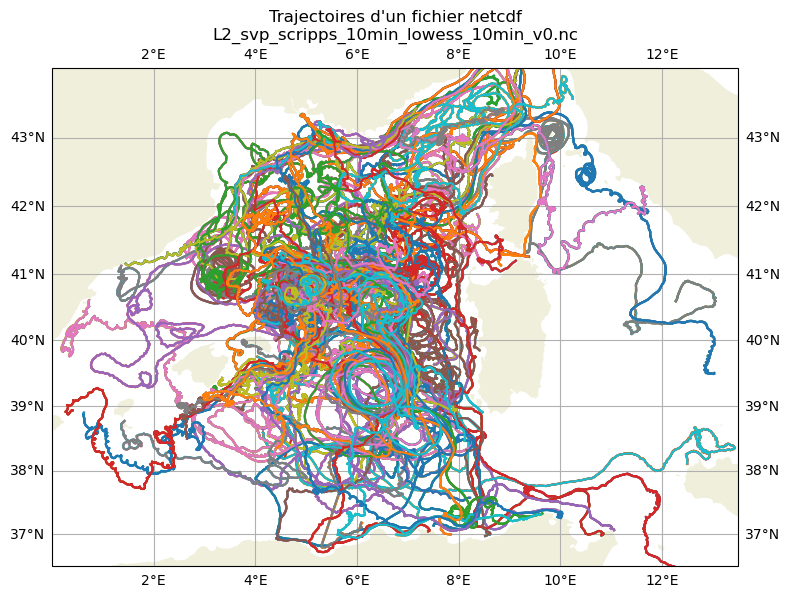

In [5]:
fig = plt.figure(tight_layout=True, figsize=(8, 8))
crs = ccrs.PlateCarree()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
gl = ax.gridlines(draw_labels=True,)

ax.add_feature(cfeature.LAND,)
bbox = [0,13.5, 36.5,44]
ax.set_extent(bbox)

for file in mediterranea_files:
    ds = xr.open_dataset(os.path.join(L2_dir, file))
    for i in range(ds.sizes['id']):
        ax.plot(ds.isel(id=i).lon, ds.isel(id=i).lat,transform=crs, label=str(i))

### SAVE
ax.set_title("All mediterranean trajectories")
save_name = 'all_mediterranean_trajectories.png'
plt.savefig(path_save_plot+save_name, bbox_inches='tight', dpi = 300)

In [61]:
ds.time

<xarray.DataArray 'time' (time: 3727)>
array(['2023-05-04T20:10:00.000000000', '2023-05-04T20:20:00.000000000',
       '2023-05-04T20:30:00.000000000', ..., '2023-05-30T16:50:00.000000000',
       '2023-05-30T17:00:00.000000000', '2023-05-30T17:10:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-05-04T20:10:00 ... 2023-05-30T17:10:00
Attributes:
    longname:  Time

## Compute and plot observation spatial density

one drifter

In [26]:
f = mediterranea_files[0]
ds = xr.open_dataset(os.path.join(L2_dir, f))

i=0
x, y = ds.isel(id=i).lon.values, ds.isel(id=i).lat.values


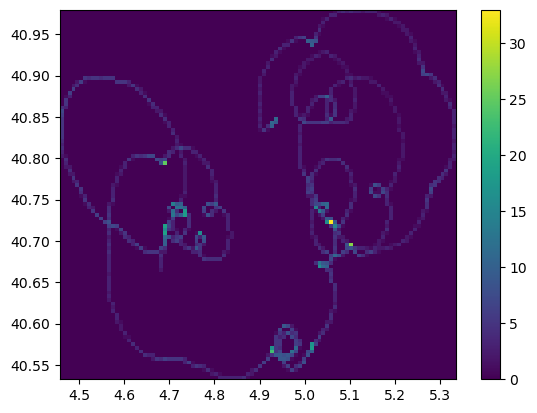

In [27]:
hist, lon_edges, lat_edges, _ = plt.hist2d(x, y, bins=100, range=None, density=False)
plt.colorbar()

#### all drifters

In [199]:
# get 1D array for latitude and longitude over all observations

all_lat, all_lon = np.array([]), np.array([])

for file in mediterranea_files:
    ds = xr.open_dataset(os.path.join(L2_dir, file))
    x, y = ds.lat.values.flatten(), ds.lon.values.flatten()
    all_lat = np.concatenate([all_lat, x])
    all_lon = np.concatenate([all_lon, y])

all_lat = all_lat[~np.isnan(all_lat)]
all_lon = all_lon[~np.isnan(all_lon)]

In [200]:
# histogram 2D of the observations number
hist, lat_edges, lon_edges = np.histogram2d(all_lat, all_lon, bins=100, range=None, density=False)

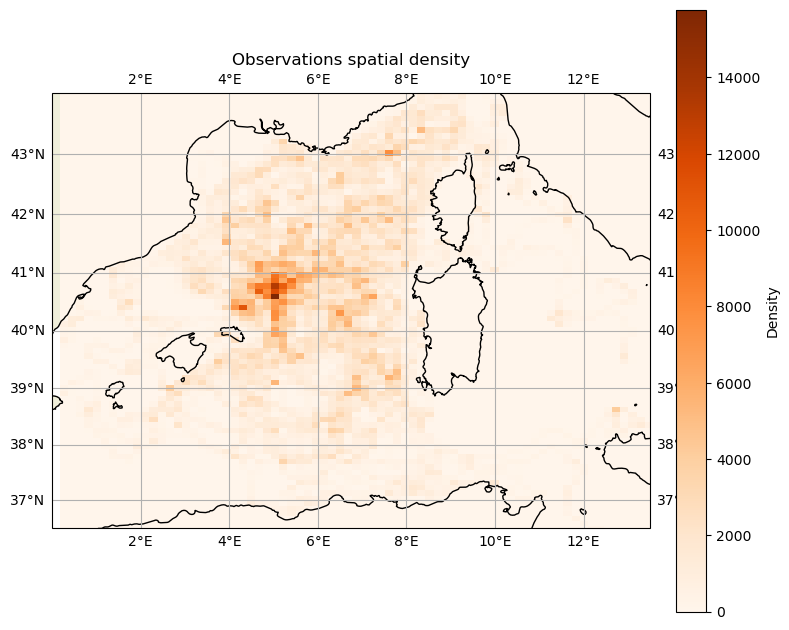

In [201]:
# Set up the figure and map projection
fig = plt.figure(tight_layout=True, figsize=(8, 8))
crs = ccrs.PlateCarree()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
gl = ax.gridlines(draw_labels=True,)

# Add land feature for better visualization
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)

# Set the map extent
bbox = [0, 13.5, 36.5, 44]
ax.set_extent(bbox, crs=crs)

# Plot the density of points
mesh = ax.pcolormesh(lon_edges, lat_edges, hist, transform=crs, cmap='Oranges')

# Add a color bar to show the density scale
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Density')

### SAVE
ax.set_title("Observations spatial density")
save_name = 'observations_spatial_density.png'
plt.savefig(path_save_plot+save_name, bbox_inches='tight', dpi = 300)

## Time repartition & temporal resolution 

In [4]:
time_med = np.array([], dtype=np.datetime64)

for file in mediterranea_files:
    ds = xr.open_dataset(os.path.join(L2_dir, file))
    time = ds.time.values.flatten()
    time_med = np.concatenate([time_med, time])

time_med = time_med[~np.isnan(time_med)]

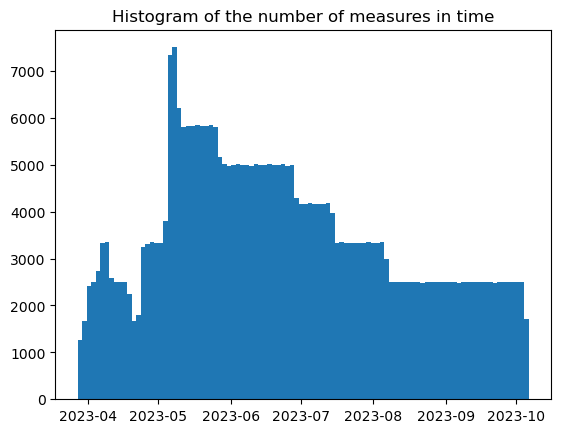

In [119]:
hist, time_edges, _ = plt.hist(time_med, bins=100)
plt.title('Histogram of the number of measures in time')
plt.show()

**There are two temporal resolution**: L1 DATA & L2 interpolated data 

In [120]:
mediterranea_files[0]

'L2_svp_scripps_10min_lowess_10min_v0.nc'